# 07 BERTopic: emergent topic discovery 

## 0. Install 

In [1]:
# !pip install bertopic sentence-transformers umap-learn hdbscan scikit-learn pandas matplotlib

## 1. Setup + CONFIG

In [2]:
!pip install bertopic sentence-transformers umap-learn hdbscan

In [3]:
import re, pandas as pd, numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"]="sans-serif"
plt.rcParams["font.sans-serif"]=["Calibri","Arial","DejaVu Sans"]
NAVY,GREEN="#085384","#1B4332"

# CONFIG 
INPUT_CSV  = "cleaned_comments_ver2.csv"   
TEXT_COL   = "comment_text"                
MIN_LEN    = 40                            
MIN_TOPIC_SIZE = 15                        
SEED       = 42


MY_CODES = ["oil_spill_risk","climate_emissions","air_quality","environmental_justice",
            "marine_wildlife","fisheries","wetlands_coast","national_interest"]


## 2. Load + deduplicate form letters


In [4]:
df = pd.read_csv(INPUT_CSV, low_memory=False)
df = df[df[TEXT_COL].astype(str).str.len() >= MIN_LEN].copy()
print(f"comments with usable text: {len(df):,}")

def norm(t): return re.sub(r"\s+"," ", re.sub(r"[^a-z0-9 ]","", str(t).lower())).strip()
df["_norm"] = df[TEXT_COL].apply(norm)

uniq = (df.groupby("_norm")
          .agg(text=(TEXT_COL,"first"), weight=(TEXT_COL,"size"))
          .reset_index(drop=True)
          .sort_values("weight", ascending=False))
docs = uniq["text"].tolist()
weights = uniq["weight"].values
print(f"unique templates to model: {len(docs):,}  (covering {int(weights.sum()):,} comments)")
print(f"top template covers {int(weights.max()):,} comments")


comments with usable text: 9,901
unique templates to model: 6,523  (covering 9,901 comments)
top template covers 1,782 comments


## 3. Fit BERTopic on the unique texts

In [5]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

embedder = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedder.encode(docs, show_progress_bar=True)

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                  metric="cosine", random_state=SEED)          # seed = reproducible
hdbscan_model = HDBSCAN(min_cluster_size=MIN_TOPIC_SIZE, metric="euclidean",
                        cluster_selection_method="eom", prediction_data=True)
vectorizer = CountVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)

topic_model = BERTopic(embedding_model=embedder, umap_model=umap_model,
                       hdbscan_model=hdbscan_model, vectorizer_model=vectorizer,
                       min_topic_size=MIN_TOPIC_SIZE, verbose=True)
topics, _ = topic_model.fit_transform(docs, embeddings)
print(f"\nfound {len(set(topics)) - (1 if -1 in topics else 0)} topics (excluding outliers)")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/204 [00:00<?, ?it/s]

2026-08-03 02:27:04,085 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-03 02:27:41,777 - BERTopic - Dimensionality - Completed ✓
2026-08-03 02:27:41,778 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-03 02:27:41,953 - BERTopic - Cluster - Completed ✓
2026-08-03 02:27:41,956 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-03 02:27:43,153 - BERTopic - Representation - Completed ✓



found 110 topics (excluding outliers)


## 4. Topic table (emergent topics + keywords)
Topic -1 = outliers (unclustered). Each topic's name is its top keywords.

In [6]:
info = topic_model.get_topic_info()
# weighted size: how many actual COMMENTS each topic covers (not just templates)
uniq2 = uniq.reset_index(drop=True).copy(); uniq2["topic"]=topics
wsize = uniq2.groupby("topic")["weight"].sum()
info["comment_weight"] = info["Topic"].map(wsize).fillna(0).astype(int)
info.to_csv("bertopic_topics.csv", index=False)

print("Top emergent topics (by comments represented):")
for _,r in info[info.Topic!=-1].sort_values("comment_weight",ascending=False).head(15).iterrows():
    kws = ", ".join([w for w,_ in topic_model.get_topic(r.Topic)][:6])
    print(f"  T{r.Topic:>2}  ~{r.comment_weight:>5} comments | {kws}")


Top emergent topics (by comments represented):
  T97  ~ 1809 comments | burdens, impacts, does, ecosystems, concerned, pollution
  T 2  ~  446 comments | reject license, reject, disasters benefiting, terminal approving, benefiting local, benefiting
  T 3  ~  386 comments | water pollution, air water, cleaner, wildlife habitats, environmental social, social
  T 0  ~  322 comments | risks, near, oil spills, spills, air, sincerely mr
  T 1  ~  194 comments | gulflink, oil, climate, gas, fossil, new
  T51  ~  165 comments | deepwater port, port license, license application, application, gulflink llc, llc
  T 4  ~  107 comments | stop, planet, earth, fossil fuels, fuels, fossil
  T89  ~  105 comments | wildlife, waters, process, opportunities, natural, spill
  T 6  ~   98 comments | leading, pollution, climate pollution, reject, lifetime, fires floods
  T 5  ~   95 comments | risks, near, oil spills, spills, air, sincerely ms
  T 7  ~   79 comments | risks, air, spills, near, oil spills, co

## 5. Topic size chart 

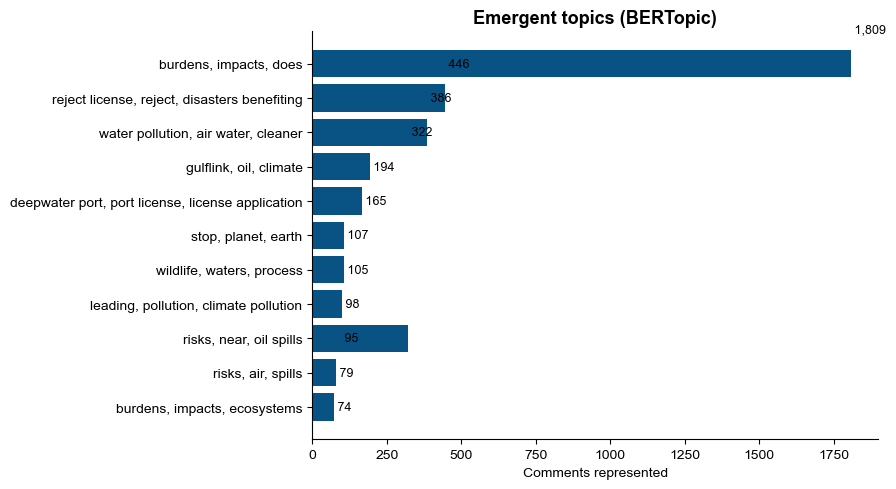

In [7]:
top = info[info.Topic!=-1].sort_values("comment_weight",ascending=False).head(12).iloc[::-1]
names = [", ".join([w for w,_ in topic_model.get_topic(t)][:3]) for t in top.Topic]
fig,ax=plt.subplots(figsize=(9,5))
ax.barh(names, top["comment_weight"], color=NAVY)
for i,v in enumerate(top["comment_weight"]): ax.text(v, i, f" {v:,}", va="center", fontsize=9)
ax.set_xlabel("Comments represented"); ax.set_title("Emergent topics (BERTopic)", fontsize=13, weight="bold")
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig("bertopic_sizes.png", dpi=150, facecolor="white"); plt.show()


## 6. Compare emergent topics to my schema 

In [8]:

CUES = {
 "oil_spill_risk":["spill","leak","blowout","deepwater horizon","accident"],
 "climate_emissions":["climate","greenhouse","emission","carbon","fossil","co2","ghg"],
 "air_quality":["air","ozone","nox","pollution","asthma","respiratory"],
 "environmental_justice":["justice","minority","low-income","indigenous","communities of color","racism"],
 "marine_wildlife":["marine","turtle","whale","dolphin","wildlife","species","habitat","bird"],
 "fisheries":["fish","shrimp","fishing","fishermen","fishery"],
 "wetlands_coast":["wetland","coast","erosion","storm","flood","sea level"],
 "national_interest":["national interest","nepa","dwpa","economy","jobs"],
}
def map_topic(t):
    kws=" ".join([w for w,_ in topic_model.get_topic(t)][:10]).lower()
    hits=[c for c,cues in CUES.items() if any(q in kws for q in cues)]
    return hits

print("Emergent topic -> your schema mapping:")
for _,r in info[info.Topic!=-1].sort_values("comment_weight",ascending=False).iterrows():
    kws=", ".join([w for w,_ in topic_model.get_topic(r.Topic)][:6])
    hits=map_topic(r.Topic)
    tag = ", ".join(hits) if hits else ">>> EMERGENT / no schema match <<<"
    print(f"  T{r.Topic:>2} ({r.comment_weight:>5}) [{tag}]  | {kws}")


Emergent topic -> your schema mapping:
  T97 ( 1809) [air_quality]  | burdens, impacts, does, ecosystems, concerned, pollution
  T 2 (  446) [>>> EMERGENT / no schema match <<<]  | reject license, reject, disasters benefiting, terminal approving, benefiting local, benefiting
  T 3 (  386) [climate_emissions, air_quality, marine_wildlife]  | water pollution, air water, cleaner, wildlife habitats, environmental social, social
  T 0 (  322) [oil_spill_risk, air_quality]  | risks, near, oil spills, spills, air, sincerely mr
  T 1 (  194) [climate_emissions]  | gulflink, oil, climate, gas, fossil, new
  T51 (  165) [oil_spill_risk]  | deepwater port, port license, license application, application, gulflink llc, llc
  T 4 (  107) [climate_emissions]  | stop, planet, earth, fossil fuels, fuels, fossil
  T89 (  105) [oil_spill_risk, marine_wildlife]  | wildlife, waters, process, opportunities, natural, spill
  T 6 (   98) [climate_emissions, air_quality, wetlands_coast]  | leading, pollution, 